# Neuron sim

In [1]:
from neuron import h
import neuron
import numpy as np
import pandas as pd
from scipy import stats as st
from scipy import signal as ss

import matplotlib.pyplot as plt
import os

In [2]:

###################### Load and organize Excel file ################################
circuit_params = {}

#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]

#  **``LFPy``** rand **``NetPyNE``**

In [3]:
circuit_params['SING_CELL_PARAM']

,HL23PYR,HL23SST,HL23PV,HL23VIP
GOU,0.000028,0.000030,0.000280,0.000066
norm_tonic,0.000938,0.000938,0.000938,0.000938
drug_tonic,0.001352,0.001030,0.001091,0.000938
apic_tonic,0.000938,0.000938,0.000938,0.000938
drug_apic_tonic,0.001352,0.001030,0.001091,0.000938
cell_num,800.000000,50.000000,70.000000,80.000000
rotate_x,3.000000,1.770000,1.260000,-1.570000
rotate_y,4.000000,2.770000,2.570000,3.570000


In [4]:
SPIKES = np.load("Circuit_output/SPIKES_Seed1234.npy", allow_pickle=True)

In [5]:
VOLTAGES = np.load("Circuit_output/VOLTAGES_Seed1234.npy", allow_pickle=True)

In [6]:
import pickle as pkl

with open("../v1_batch1/v1_batch1_data.pkl", "rb") as f:
    data = pkl.load(f)

with open("../v1_batch2/v1_batch2_data.pkl", "rb") as f2:
    data2 = pkl.load(f2)

print("Loaded data type:", type(data))
if hasattr(data, "keys"):
    print("Keys:", list(data.keys()), list(data2.keys()))
else:
    print("Data len:", len(data), len(data2))

Loaded data type: <class 'dict'>
Keys: ['netpyne_version', 'netpyne_changeset', 'net', 'simConfig', 'simData'] ['netpyne_version', 'netpyne_changeset', 'net', 'simConfig', 'simData']


In [7]:
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)
N_HL23PYR = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PYR'])
N_HL23SST = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23SST'])
N_HL23PV = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PV'])
N_HL23VIP = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23VIP'])

N_cells = N_HL23PYR + N_HL23SST + N_HL23PV + N_HL23VIP

# cell_indices_to_plot = [0, 1, N_HL23PYR, N_HL23PYR + 1, N_HL23PYR + N_HL23SST, N_HL23PYR + N_HL23SST + 1, N_HL23PYR + N_HL23SST + N_HL23PV, N_HL23PYR + N_HL23SST + N_HL23PV + 1]
# cell_indices_to_plot = range(10, 50)

cell_indices_to_plot = []
for j in range(10):
   cell_indices_to_plot = cell_indices_to_plot + [10 + j, 
                        N_HL23PYR + j, 
                        N_HL23PYR + N_HL23SST + j, 
                        N_HL23PYR + N_HL23SST + N_HL23PV + j]
# cell_indices_to_plot

In [8]:
data['simData']['V_soma'].keys()

dict_keys(['cell_0', 'cell_800', 'cell_920', 'cell_1', 'cell_801', 'cell_921', 'cell_850', 'cell_851'])

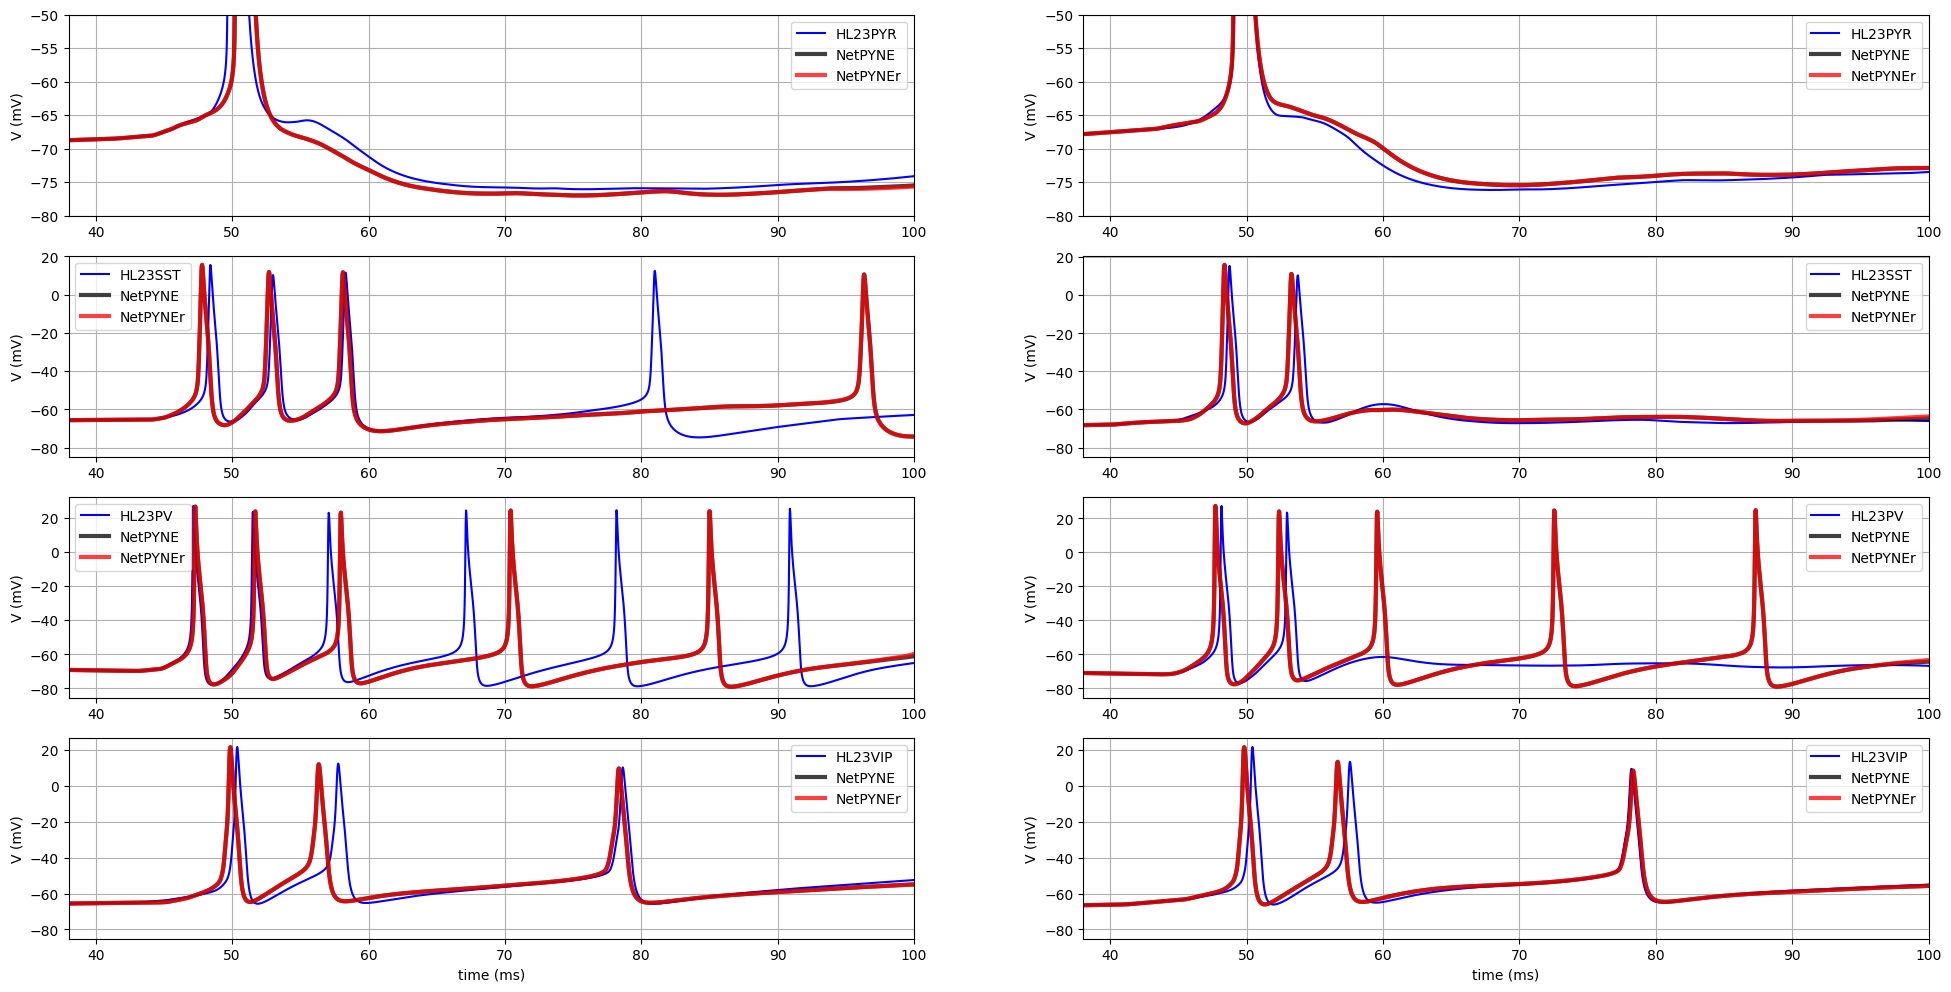

In [20]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 10000, 10000/n_samples)

cells = ['cell_0', 'cell_1', 'cell_800', 'cell_801', 'cell_850', 'cell_851', 'cell_920', 'cell_921']

# cells = ["cell_"+str(i) for i in range(20,30)] + ["cell_"+str(i) for i in range(N_HL23PYR,N_HL23PYR + 10)]  + ["cell_"+str(i) for i in range(N_HL23PYR + N_HL23SST,N_HL23PYR + N_HL23SST + 10)]  + ["cell_"+str(i) for i in range(N_HL23PYR + N_HL23SST + N_HL23PV,N_HL23PYR + N_HL23SST + N_HL23PV + 10)]

fig = plt.figure(figsize=(24, 12))
ii = 0
for i in range(4):
    for j in range(2):
        plt.subplot(4,2, ii+1)
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label=pop_names[i], color='blue')
        plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.75, linewidth=3)
        plt.plot(data['simData']['t'], data2['simData']['V_soma'][cells[ii]], label="NetPYNEr", color='r', alpha = 0.75, linewidth=3)
        ii = ii + 1
        plt.ylabel('V (mV)')
        plt.xlim(38, 100.0)
        # plt.xlim(42, 46.0)
        # plt.ylim(-84, -70)
        plt.legend()
        plt.grid(True)
        if i == 3:
            plt.xlabel('time (ms)')
        if i == 0:
            plt.ylim(-80, -50)
plt.show()

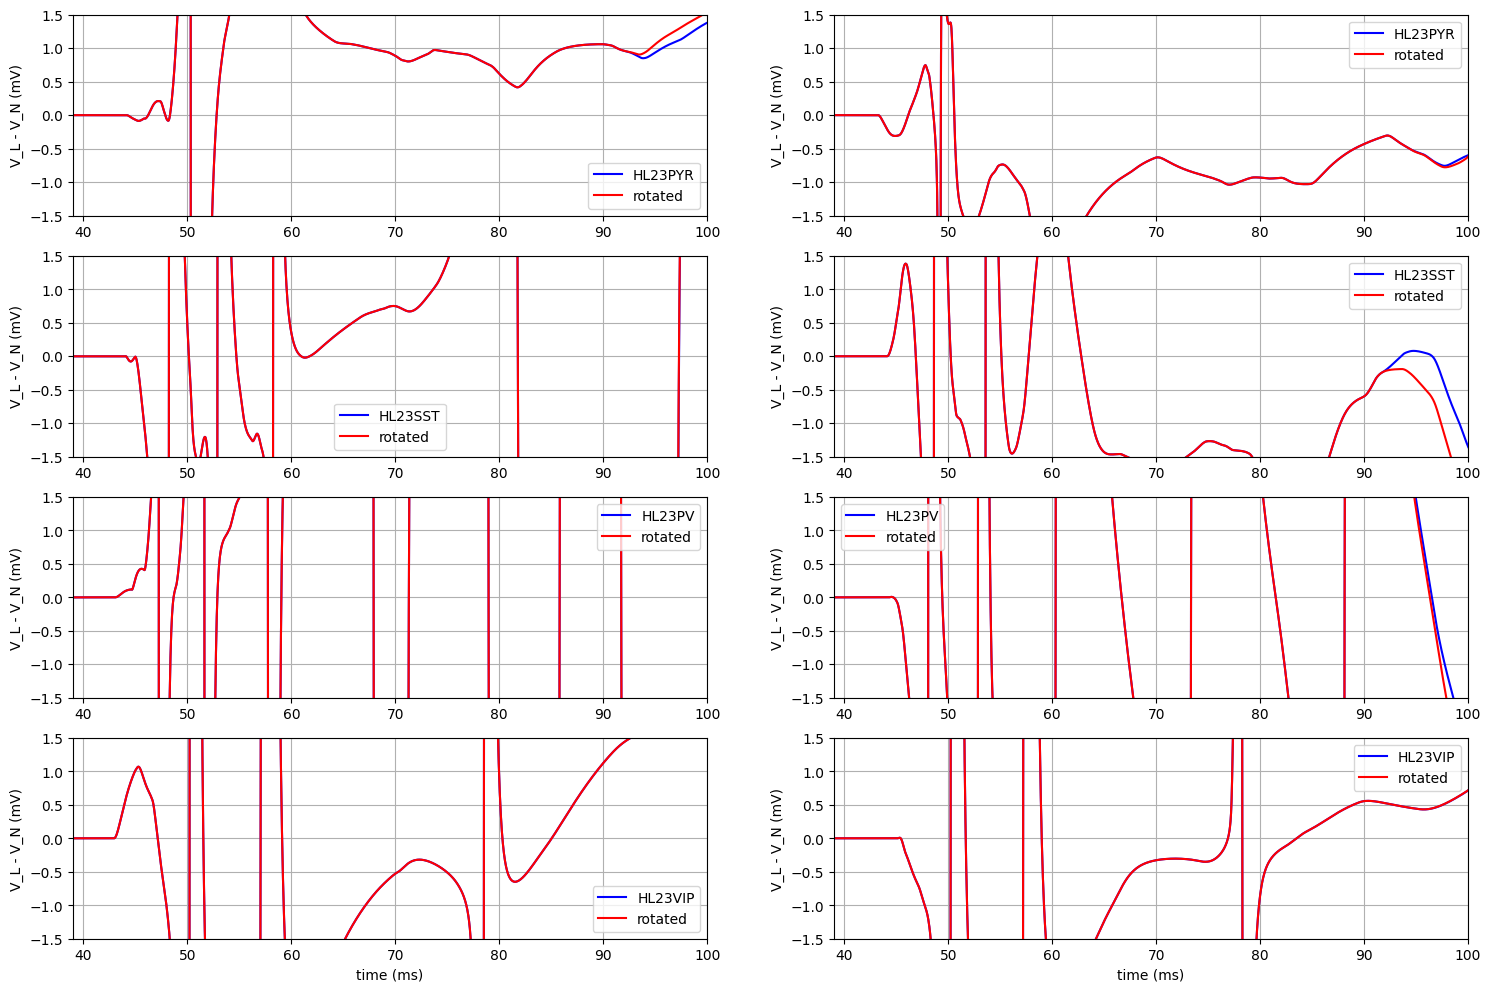

In [10]:
fig = plt.figure(figsize=(18, 12))
ii = 0
for i in range(4):
    for j in range(2):
        plt.subplot(4,2, ii+1)
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j])-data['simData']['V_soma'][cells[ii]], label=pop_names[i], color='blue')
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j])-data2['simData']['V_soma'][cells[ii]], label="rotated", color='red')
        ii = ii + 1
        plt.ylabel('V_L - V_N (mV)')
        plt.xlim(39, 100.0)
        plt.ylim(-1.5, 1.5)
        plt.legend()
        plt.grid(True)
        if i == 3:
            plt.xlabel('time (ms)')
plt.show()

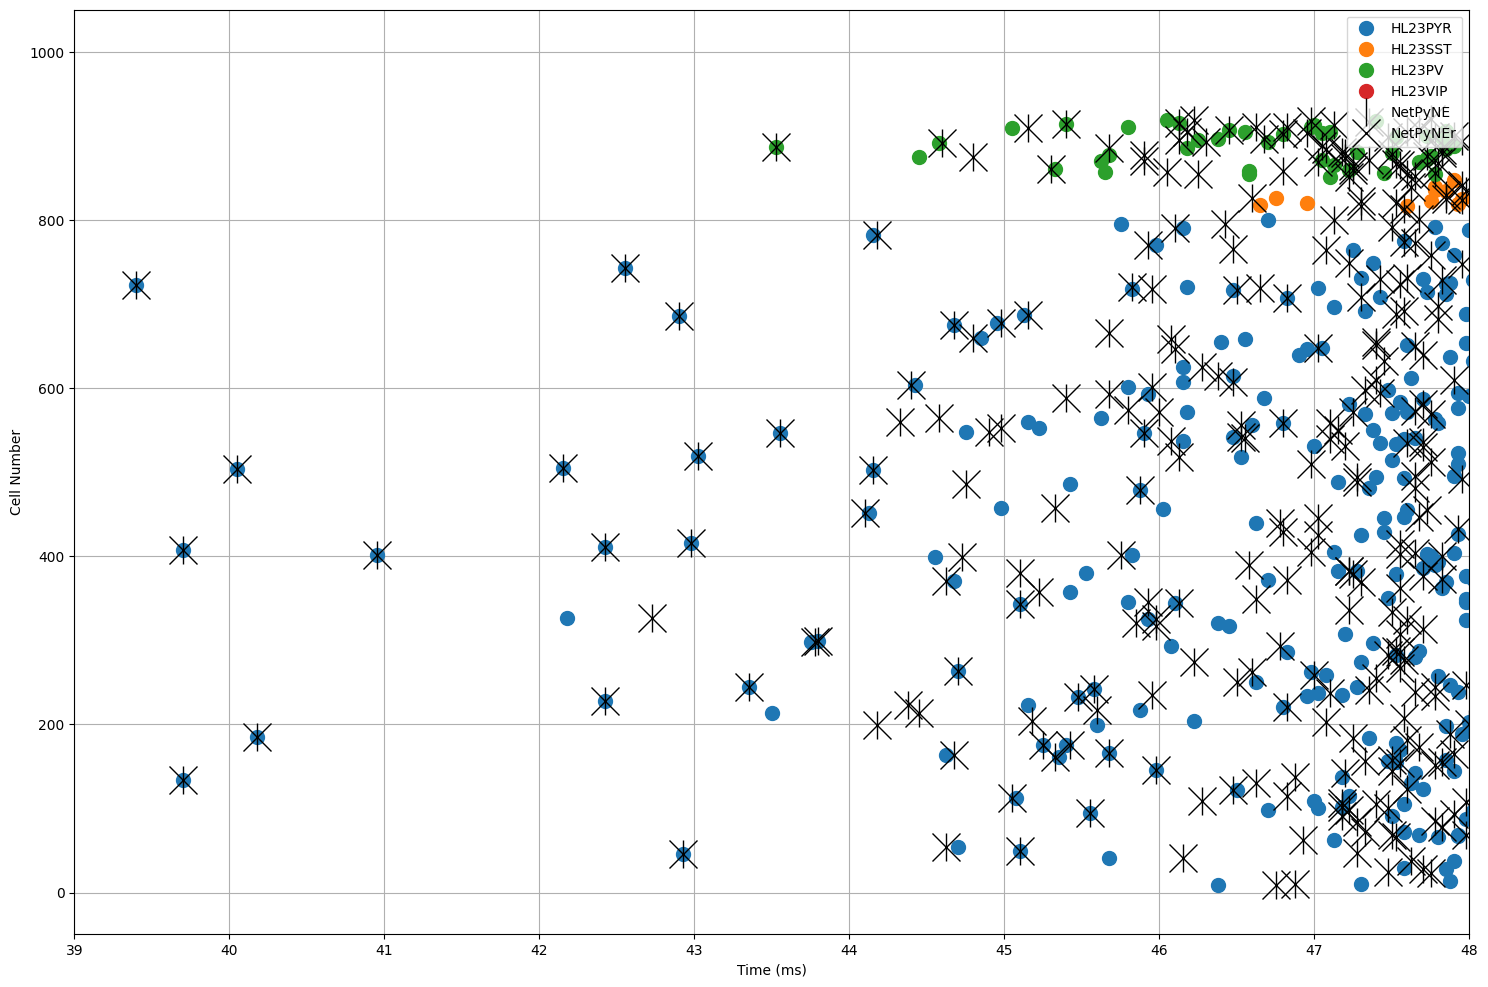

In [21]:

def remove_axis_junk(ax, lines=['right', 'top']):
    """remove chosen lines from plotting axis"""
    for loc, spine in ax.spines.items():
        if loc in lines:
            spine.set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def plot_raster(SPIKES, cell_names):
        tinit = 0
        tend = 100000
        
        colors = ['dimgray', 'crimson', 'green', 'darkorange']
        pop_colors = {'HL23PYR':'dimgray', 'HL23SST':'crimson', 'HL23PV':'green', 'HL23VIP':'darkorange'}
        popnames = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']
        pop_Number = {'HL23PYR': 800, 'HL23SST': 50, 'HL23PV': 70, 'HL23VIP': 80}
        # pop_Number = {'HL23PYR': 10, 'HL23SST': 10, 'HL23PV': 10, 'HL23VIP': 10}
        firing_rate = {}
        # spike raster
        fig, ax = plt.subplots(1, 1, figsize=(18, 12))
        for name, spts, gids in zip(
                cell_names, SPIKES.item()['times'], SPIKES.item()['gids']):
            t = []
            g = []
            for spt, gid in zip(spts, gids):
                t = np.r_[t, spt]
                g = np.r_[g, np.zeros(spt.size) + gid]
            ax.plot(t[(t >= tinit) & (t < tend)], g[(t >= tinit) & (t < tend)]+1, 'o', ms=10, label=name)#, color=pop_colors[name])
            # print(name, (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name]))
            firing_rate[name] = (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name])
        # ax.set_ylim(415, -15)
        # ax.set_xlim(tinit + 250, tend - 250)
        ax.plot(data['simData']['spkt'], np.array(data['simData']['spkid'])+1, 'k|', ms=20, label="NetPyNE")
        ax.plot(data2['simData']['spkt'], np.array(data2['simData']['spkid'])+1, 'kx', ms=20, label="NetPyNEr")
        ax.set_xlim(39, 48)
        # ax.set_ylim(0, 13)
        # ax.set_xticks([4000, 4500, 5000])
        # ax.set_xlim(8500, 9000)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Cell Number')
        ax.legend(loc=1)
        ax.grid(True)

        return

plot_raster(SPIKES, cell_names)